In [1]:
!pip install -q scikit-learn   # for accuracy_score, confusion_matrix
!pip install -q seaborn        # for prettier confusion matrix heatmap
# (gradio is optional — only needed for Section 6 bonus demo)
 
print('All extra packages installed!')


All extra packages installed!


In [2]:
# ─── Cell 2: Import all required libraries ───────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os
import warnings

warnings.filterwarnings('ignore')

# ── Detect device ─────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device in use : {device}')
print(f'PyTorch version: {torch.__version__}')

Device in use : cuda
PyTorch version: 2.10.0+cu128


In [3]:
# ─── Cell 3: Define transforms for training and validation ───────────

train_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),

    transforms.RandomCrop(32, padding=4),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# VALIDATION / TEST TRANSFORMS

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms defined successfully!')
print(' Training : resize + augmentation + normalize')
print(' Validation: resize + normalize only')

Transforms defined successfully!
 Training : resize + augmentation + normalize
 Validation: resize + normalize only


In [4]:
# ─── Cell 4: Download CIFAR-10 and create mini subset ────────────────

print('Downloading CIFAR-10 dataset...')

full_train_raw = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

full_test_raw = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_transform
)

print(f'Full training set: {len(full_train_raw):,} images')
print(f'Full test set : {len(full_test_raw):,} images')

# ── Helper function ───────────────────────────────────────────────────

import random

random.seed(42)

def make_balanced_subset(dataset, n_per_class=500, num_classes=10):

    targets = dataset.targets

    indices_per_class = {c: [] for c in range(num_classes)}

    for idx, label in enumerate(targets):
        indices_per_class[label].append(idx)

    selected = []

    for c in range(num_classes):
        pool = indices_per_class[c]
        random.shuffle(pool)
        selected.extend(pool[:n_per_class])

    random.shuffle(selected)

    return Subset(dataset, selected)

# Create mini subsets

mini_train_full = make_balanced_subset(full_train_raw, n_per_class=500)

mini_test = make_balanced_subset(full_test_raw, n_per_class=100)

print(f'Mini training set: {len(mini_train_full)} images')
print(f'Mini test set : {len(mini_test)} images')

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

100%|██████████| 170M/170M [00:02<00:00, 57.8MB/s] 


Full training set: 50,000 images
Full test set : 10,000 images
Mini training set: 5000 images
Mini test set : 1000 images
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
# ─── Cell 5: Split dataset ───────────────────────────────────────────

train_size = int(0.8 * len(mini_train_full))

val_size = len(mini_train_full) - train_size

train_dataset, val_dataset = random_split(
    mini_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = mini_test

print('Dataset split summary:')
print(f' Training   : {len(train_dataset)}')
print(f' Validation : {len(val_dataset)}')
print(f' Test       : {len(test_dataset)}')

Dataset split summary:
 Training   : 4000
 Validation : 1000
 Test       : 1000


In [6]:
# ─── Cell 6: Create DataLoaders ──────────────────────────────────────

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'DataLoaders created (batch size = {BATCH_SIZE})')

DataLoaders created (batch size = 32)


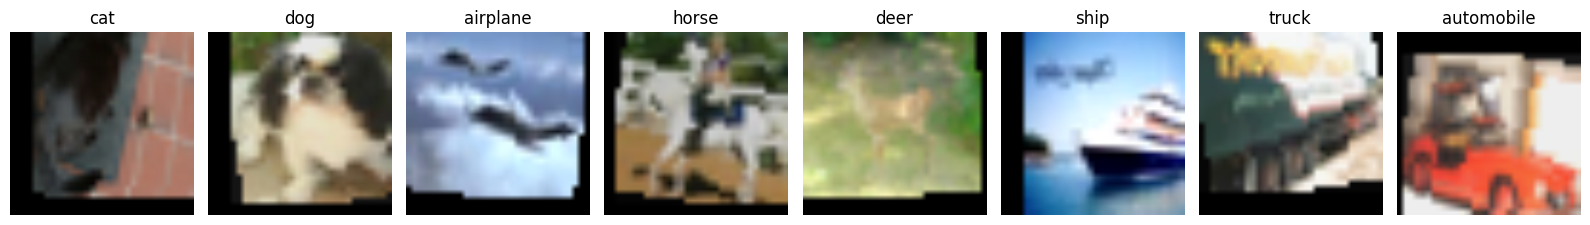

In [7]:
# ─── Cell 7: Display sample images ───────────────────────────────────

def denormalize(tensor):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    return (tensor * std) + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for i in range(8):

    img = denormalize(images[i]).permute(1, 2, 0).numpy()

    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    axes[i].set_title(class_names[labels[i].item()])

    axes[i].axis('off')

plt.tight_layout()

plt.show()

In [8]:
# ─── Cell 8: Load pretrained ResNet18 ────────────────────────────────

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print(model.fc)

# Freeze pretrained layers

for param in model.parameters():
    param.requires_grad = False

NUM_CLASSES = 10

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total = sum(p.numel() for p in model.parameters())

print(f'Trainable parameters : {trainable:,}')
print(f'Total parameters     : {total:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s] 


Linear(in_features=512, out_features=1000, bias=True)
Trainable parameters : 5,130
Total parameters     : 11,181,642


In [9]:
# ─── Cell 9: Configure training ──────────────────────────────────────

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print('Training components ready!')

Training components ready!


In [10]:
# ─── Cell 10: Training functions ─────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        if batch_idx % 50 == 0:
            print(f'Batch {batch_idx}/{len(loader)} Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(loader)

    accuracy = 100 * correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)

    accuracy = 100 * correct / total

    return avg_loss, accuracy

print('Functions defined!')

Functions defined!


In [11]:
# ─── Cell 11: Main training loop ─────────────────────────────────────

NUM_EPOCHS = 10

best_val_acc = 0.0

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

for epoch in range(1, NUM_EPOCHS + 1):

    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Train Loss: {train_loss:.4f}')
    print(f'Train Accuracy: {train_acc:.2f}%')

    print(f'Val Loss: {val_loss:.4f}')
    print(f'Val Accuracy: {val_acc:.2f}%')

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), 'best_model.pth')

        print('Best model saved!')

print(f'\nBest Validation Accuracy: {best_val_acc:.2f}%')


Epoch 1/10
Batch 0/125 Loss: 2.4647
Batch 50/125 Loss: 1.9808
Batch 100/125 Loss: 1.3145
Train Loss: 1.7844
Train Accuracy: 39.50%
Val Loss: 1.3909
Val Accuracy: 53.00%
Best model saved!

Epoch 2/10
Batch 0/125 Loss: 1.4783
Batch 50/125 Loss: 1.1699
Batch 100/125 Loss: 1.1407
Train Loss: 1.2526
Train Accuracy: 59.52%
Val Loss: 1.1161
Val Accuracy: 63.20%
Best model saved!

Epoch 3/10
Batch 0/125 Loss: 0.8873
Batch 50/125 Loss: 1.1886
Batch 100/125 Loss: 1.2369
Train Loss: 1.0932
Train Accuracy: 63.83%
Val Loss: 1.0678
Val Accuracy: 62.90%

Epoch 4/10
Batch 0/125 Loss: 1.0874
Batch 50/125 Loss: 0.8848
Batch 100/125 Loss: 0.9167
Train Loss: 1.0309
Train Accuracy: 64.78%
Val Loss: 0.9821
Val Accuracy: 66.40%
Best model saved!

Epoch 5/10
Batch 0/125 Loss: 0.8312
Batch 50/125 Loss: 0.6282
Batch 100/125 Loss: 0.8483
Train Loss: 0.9584
Train Accuracy: 68.35%
Val Loss: 0.9852
Val Accuracy: 66.00%

Epoch 6/10
Batch 0/125 Loss: 0.9407
Batch 50/125 Loss: 0.8812
Batch 100/125 Loss: 1.1650
Train 

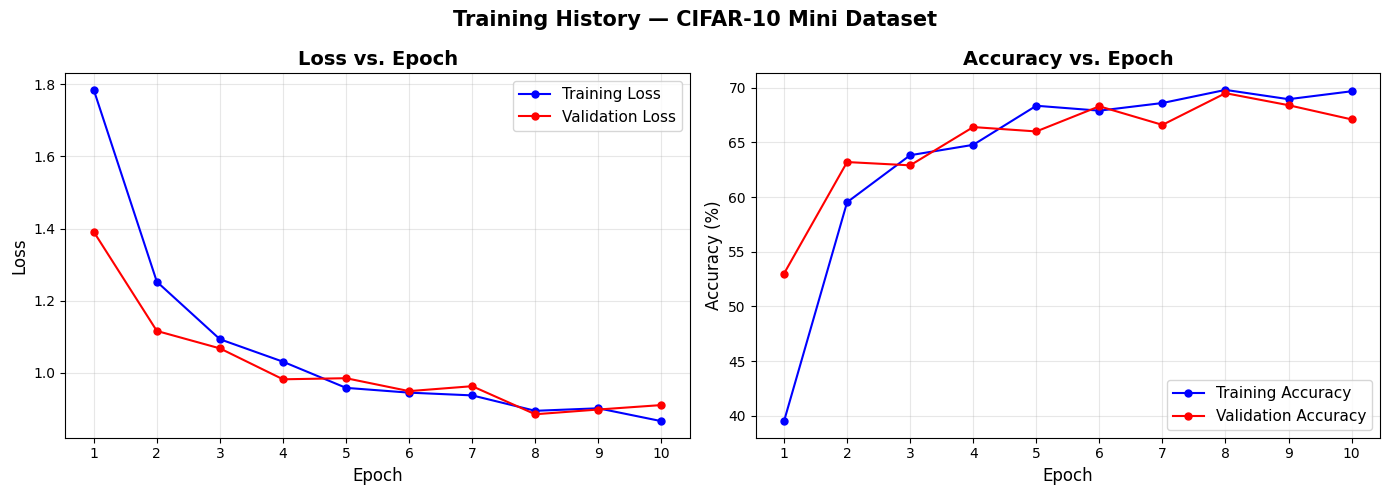

Good! Train-val gap is 2.6% -- model generalises well.


In [12]:
# ─── Cell 12: Plot loss and accuracy curves ───────────────────────────
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
epochs_range = range(1, NUM_EPOCHS + 1)
 
# ── Loss subplot ──────────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss',   markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', markersize=5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss vs. Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(epochs_range))
 
# ── Accuracy subplot ──────────────────────────────────────────────────
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy',   markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', markersize=5)
ax2.set_xlabel('Epoch',       fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy vs. Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(epochs_range))
 
plt.suptitle('Training History — CIFAR-10 Mini Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
 
# ── Overfitting check ─────────────────────────────────────────────────
final_gap = history['train_acc'][-1] - history['val_acc'][-1]
 
if final_gap > 15:
    print(f'WARNING: Large train-val gap ({final_gap:.1f}%) -- possible overfitting!')
    print('Fix: add more augmentation, or reduce learning rate.')
elif final_gap < -5:
    print(f'NOTE: Validation ({history["val_acc"][-1]:.1f}%) > Training ({history["train_acc"][-1]:.1f}%)')
    print('This can happen with strong augmentation -- usually fine.')
else:
    print(f'Good! Train-val gap is {final_gap:.1f}% -- model generalises well.')


In [13]:
# ─── Cell 13: Evaluate on the held-out test set ──────────────────────
 
# Load the best model weights saved during training
# map_location=device handles the case where you saved on GPU but load on CPU
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()   # always set eval mode before inference!
 
all_preds  = []    # will hold predicted class indices
all_labels = []    # will hold true class indices
 
with torch.no_grad():   # no gradients needed for evaluation
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)              # raw scores (logits)
        _, predicted = torch.max(outputs, dim=1)  # pick highest-score class
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
 
# ── Overall accuracy ─────────────────────────────────────────────────
test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
 
# ── Per-class classification report ──────────────────────────────────
# Precision: of all predictions for class X, how many were correct?
# Recall:    of all real class X images, how many did we catch?
# F1-score:  harmonic mean of precision and recall (balanced metric)
print('\nClassification Report:')
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=3             # show 3 decimal places
))


Test Accuracy: 0.7330  (73.30%)

Classification Report:
              precision    recall  f1-score   support

    airplane      0.780     0.710     0.743       100
  automobile      0.677     0.900     0.773       100
        bird      0.592     0.740     0.658       100
         cat      0.612     0.630     0.621       100
        deer      0.797     0.510     0.622       100
         dog      0.757     0.780     0.768       100
        frog      0.681     0.940     0.790       100
       horse      0.968     0.600     0.741       100
        ship      0.796     0.860     0.827       100
       truck      0.904     0.660     0.763       100

    accuracy                          0.733      1000
   macro avg      0.756     0.733     0.731      1000
weighted avg      0.756     0.733     0.731      1000



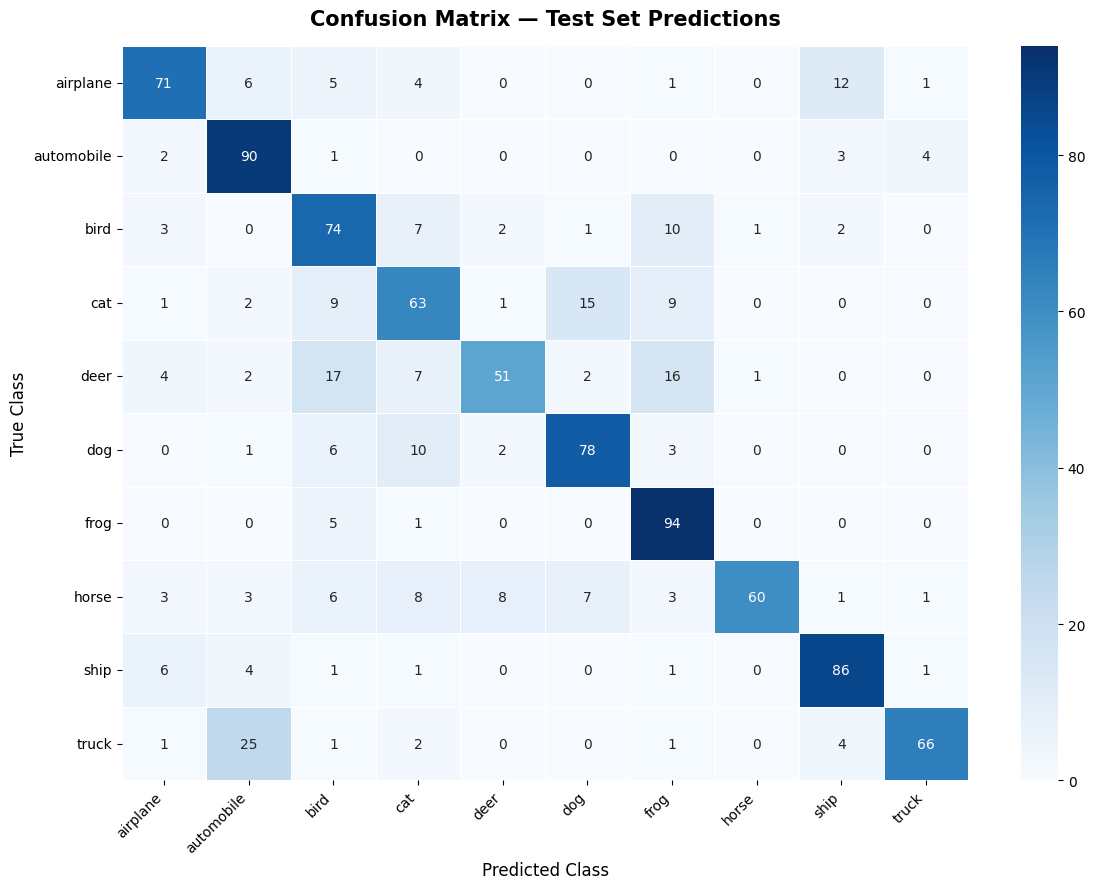

Most common mistake:
  True class  : truck
  Predicted as: automobile
  Times        : 25

Per-class accuracy:
  airplane     ##############       71.0%
  automobile   ##################   90.0%
  bird         ##############       74.0%
  cat          ############         63.0%
  deer         ##########           51.0%
  dog          ###############      78.0%
  frog         ##################   94.0%
  horse        ############         60.0%
  ship         #################    86.0%
  truck        #############        66.0%


In [14]:
# ─── Cell 14: Confusion matrix visualisation ─────────────────────────
 
# A confusion matrix shows where the model makes mistakes.
# Rows = true class  |  Columns = predicted class
# Diagonal cells    = correct predictions (we want these to be large)
# Off-diagonal cells = mistakes (what the model confused with what)
 
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,           # show the count number in each cell
    fmt='d',              # format as integer (no decimals)
    cmap='Blues',         # blue colour map
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Confusion Matrix — Test Set Predictions', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
 
# ── Find the most confused pair ───────────────────────────────────────
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)   # zero out correct predictions
worst   = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
print(f'Most common mistake:')
print(f'  True class  : {class_names[worst[0]]}')
print(f'  Predicted as: {class_names[worst[1]]}')
print(f'  Times        : {cm_copy[worst]}')
 
# ── Per-class accuracy ────────────────────────────────────────────────
per_class = cm.diagonal() / cm.sum(axis=1)
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    bar = '#' * int(per_class[i] * 20)
    print(f'  {name:12s} {bar:<20} {per_class[i]:.1%}')


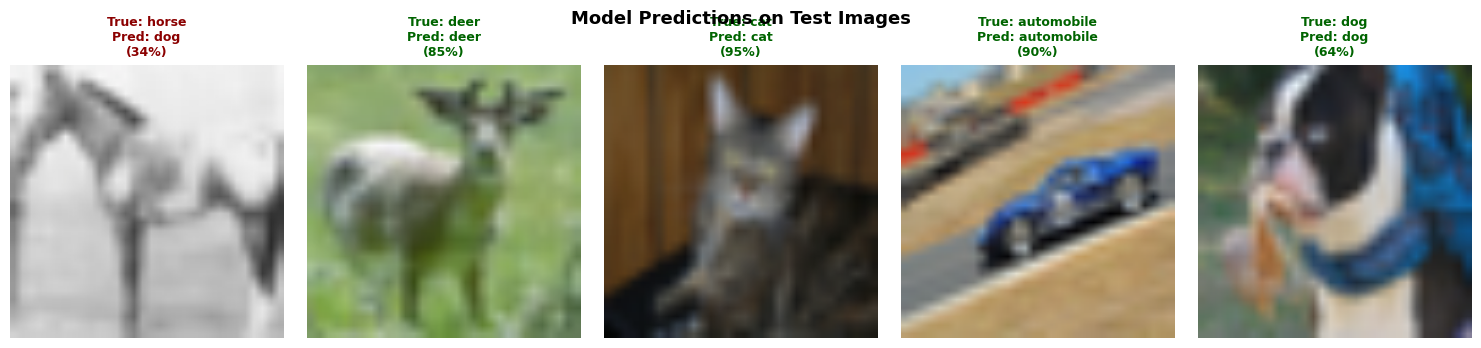

Green titles = correct  |  Red titles = incorrect


In [15]:
# ─── Cell 15: Show predictions on 5 test images side by side ─────────
 
# Grab one batch from the test loader
test_images, test_labels = next(iter(test_loader))
 
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
 
model.eval()
 
for i in range(5):
 
    # Denormalize for display (reverse the Normalize transform)
    img_display = denormalize(test_images[i]).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)
 
    # Run prediction on this single image
    # .unsqueeze(0) adds the batch dimension: (C,H,W) → (1,C,H,W)
    single_input = test_images[i].unsqueeze(0).to(device)
 
    with torch.no_grad():
        output = model(single_input)              # shape: (1, 10)
        prob   = torch.nn.functional.softmax(output[0], dim=0)
        pred   = torch.argmax(prob).item()
        conf   = prob[pred].item()
 
    # Title: green if correct, red if wrong
    true_lbl = class_names[test_labels[i].item()]
    pred_lbl = class_names[pred]
    colour   = 'darkgreen' if pred == test_labels[i].item() else 'darkred'
 
    axes[i].imshow(img_display)
    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n({conf:.0%})',
        fontsize=9, fontweight='bold', color=colour
    )
    axes[i].axis('off')
 
plt.suptitle('Model Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Green titles = correct  |  Red titles = incorrect')


In [16]:
# ─── Cell 16: predict_image() — works on any JPG/PNG file ────────────
 
def predict_image(image_path, model, class_names, device):
    """
    Load an image file, preprocess it, and return the predicted class.
 
    Args:
        image_path  : string path to any .jpg or .png file
        model       : trained PyTorch model (must be in eval() mode)
        class_names : list of class name strings
        device      : 'cuda' or 'cpu'
 
    Returns:
        predicted_class : string name of predicted class
        confidence      : float in [0, 1]  (e.g. 0.87 means 87% confident)
    """
    # ── Step 1: Load image ────────────────────────────────────────────
    # .convert('RGB') ensures colour images regardless of source format
    image = Image.open(image_path).convert('RGB')
 
    # ── Step 2: Apply EXACTLY the same preprocessing as validation ─────
    # This is critical — any mismatch here causes poor predictions
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])
 
    # ── Step 3: Prepare tensor ────────────────────────────────────────
    tensor = preprocess(image)        # shape: (3, 224, 224)
    tensor = tensor.unsqueeze(0)      # add batch dim: (1, 3, 224, 224)
    tensor = tensor.to(device)
 
    # ── Step 4: Run inference ─────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)       # raw scores, shape (1, 10)
 
    # ── Step 5: Convert to probabilities and get top prediction ───────
    probs = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, pred_idx = torch.max(probs, dim=0)
    predicted_class = class_names[pred_idx.item()]
 
    # ── Step 6: Display image + top-5 bar chart ───────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
    ax1.imshow(image)
    ax1.set_title(
        f'Predicted: {predicted_class.upper()}\nConfidence: {confidence.item():.1%}',
        fontsize=13, fontweight='bold', color='navy'
    )
    ax1.axis('off')
 
    # Top-5 probability bar chart
    top5_probs, top5_idx = torch.topk(probs, 5)
    top5_names  = [class_names[i.item()] for i in top5_idx]
    top5_values = [p.item() * 100 for p in top5_probs]
 
    colours = ['#1565C0' if i == 0 else '#90CAF9' for i in range(5)]
    ax2.barh(top5_names[::-1], top5_values[::-1], color=colours[::-1])
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)
 
    for j, (val, name) in enumerate(zip(top5_values[::-1], top5_names[::-1])):
        ax2.text(val + 1, j, f'{val:.1f}%', va='center', fontsize=10)
 
    plt.tight_layout()
    plt.show()
 
    return predicted_class, confidence.item()
 
 
print('predict_image() function defined and ready!')
print("Usage:  predict_image('path/to/my_photo.jpg', model, class_names, device)")


predict_image() function defined and ready!
Usage:  predict_image('path/to/my_photo.jpg', model, class_names, device)


Saved sample image.  True class: horse


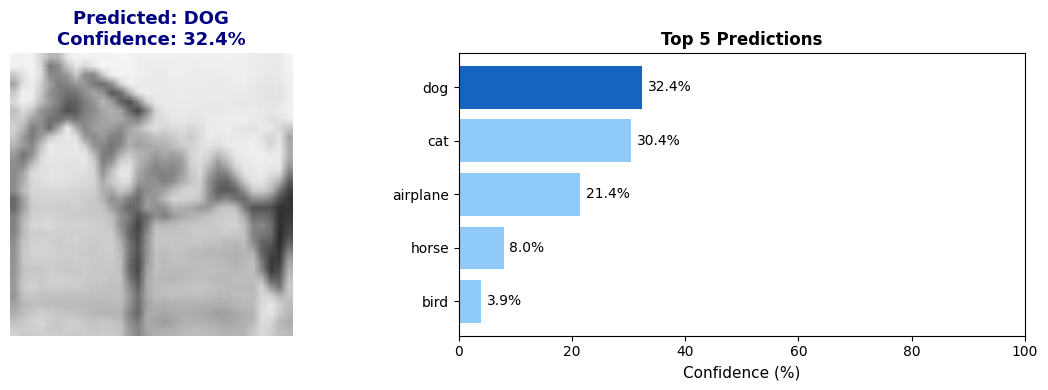

Predicted: dog  |  Confidence: 32.4%
WRONG — true class was horse


In [17]:
# ─── Cell 17: Test predict_image() using an image from the test set ──
 
# We save one test image to disk first so we can test the function
sample_img_tensor, sample_label = test_dataset[0]
 
# Denormalize and convert to PIL Image for saving
sample_pil = denormalize(sample_img_tensor).permute(1, 2, 0).numpy()
sample_pil = np.clip(sample_pil * 255, 0, 255).astype(np.uint8)
pil_img    = Image.fromarray(sample_pil)
pil_img.save('sample_test_image.jpg')
 
true_class = class_names[sample_label]
print(f'Saved sample image.  True class: {true_class}')
 
# Now run the inference function on it
pred, conf = predict_image('sample_test_image.jpg', model, class_names, device)
print(f'Predicted: {pred}  |  Confidence: {conf:.1%}')
 
if pred == true_class:
    print('CORRECT prediction!')
else:
    print(f'WRONG — true class was {true_class}')


In [35]:
# ─── Cell 18: Save a complete checkpoint and load it back ────────────
 
# ── Save a rich checkpoint (more information than just state_dict) ────
checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : class_names,
    'num_classes'         : NUM_CLASSES,
    'architecture'        : 'resnet18',
    'training_history'    : history
}
torch.save(checkpoint, 'cifar10_mini_checkpoint.pth')
print('Checkpoint saved to cifar10_mini_checkpoint.pth')
 
# ── Load the checkpoint and rebuild the model ─────────────────────────
def load_checkpoint(checkpoint_path, device):
    """Rebuild a ResNet18 classifier from a saved checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=device)
 
    # Recreate the same architecture
    loaded_model = models.resnet18(weights=None)  # no pretrained weights
    loaded_model.fc = nn.Linear(
        loaded_model.fc.in_features,
        ckpt['num_classes']
    )
 
    # Load our trained weights into the architecture
    loaded_model.load_state_dict(ckpt['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()       # always set eval mode after loading!
 
    print(f"Loaded model from {checkpoint_path}")
    print(f"Best validation accuracy: {ckpt['best_val_acc']:.2f}%")
    return loaded_model, ckpt['class_names']
 
# Verify the load works
reloaded_model, reloaded_classes = load_checkpoint('cifar10_mini_checkpoint.pth', device)
print(f'Classes: {reloaded_classes}')


Checkpoint saved to cifar10_mini_checkpoint.pth
Loaded model from cifar10_mini_checkpoint.pth
Best validation accuracy: 69.90%
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [19]:
plt.savefig("/kaggle/working/training_curves.png")


<Figure size 640x480 with 0 Axes>

In [20]:
plt.savefig("/kaggle/working/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>